# Inicialización

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # allow importing from parent directory
from fun_gilles import *
import pickle
import pandas as pd

In [2]:
colors = plt.get_cmap('Set2').colors
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["axes.formatter.useoffset"]= False

In [3]:
title_fs = 16
label_fs = 15
tick_fs = 14
legend_fs = 14

In [4]:
f = '../examples/reactions_autocat.txt'
reactions = read_file(f)
species = obtain_species(reactions)

In [5]:
def plot(abundances, times, V, SPECIES):
    colors = plt.get_cmap('Set2').colors
    colors = colors

    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(7,5)) 

    # --- Subplot 1: Concentration ---
    ax1 = axes[0]
    for i in range(len(SPECIES)):
        # Calculate concentration = Abundance / Volume
        ax1.plot(times, abundances[:, i] / V, label=SPECIES[i], color=colors[i], alpha=0.9, linewidth= 2)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_xlabel("Time", fontsize= label_fs)
    ax1.set_ylabel("Concentration", fontsize= label_fs)
    ax1.set_title("Concentration Evolution", fontsize= title_fs)
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="SPECIES", fontsize= legend_fs)
    ax1.tick_params(axis='both', labelsize=tick_fs)

    # --- Subplot 2: Volume ---
    ax2 = axes[1]
    ax2.plot(times, V, color='gray',alpha=0.9,linewidth= 2)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.set_xlabel("Time", fontsize= label_fs)
    ax2.set_ylabel("Volume", fontsize= label_fs)
    ax2.set_title("Volume Evolution", fontsize= title_fs)
    ax2.tick_params(axis='both', labelsize=tick_fs)
   
    plt.tight_layout(rect=[0, 0, 1, 1]) 
    plt.show()

In [6]:
def load_streamed_pickle(filename):
    data = {}
    try:
        with open(filename, "rb") as file:
            while True:
                try:
                    # Load one object (which is a dict of {k_i: (abundances, times, volumes)})
                    chunk = pickle.load(file)
                    # Merge the loaded chunk into the main dictionary
                    data.update(chunk)
                except EOFError:
                    # Reached the end of the file
                    break
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    
    print(f"Successfully loaded {len(data)} simulation results.")
    return data

In [7]:
def get_alpha_single_run(cond:float, result:tuple, values_used = None):
    _, times, volumes = result
        
    times = np.array(times)
    volumes = np.array(volumes)
    
    # Use data points from index len/5 onwards
    if values_used == None:
        start_idx = round(len(volumes) / 5)
        log_v = np.log(volumes[start_idx:])
        t_subset = times[start_idx:]
    
    else:
        values_used = round(len(volumes) * values_used)
        log_v = np.log(volumes[:values_used])
        t_subset = times[:values_used]
    
    # Perform linear regression
    # polyfit(x, y, 1) returns [slope, intercept]
    coefficients = np.polyfit(t_subset, log_v, 1)
    m_fit = coefficients[0]      # This is alpha (slope)
    log_A_fit = coefficients[1]  # This is the intercept
    A_fit = np.exp(log_A_fit)
    
    # --- R-SQUARED CALCULATION ---
    log_v_predicted = log_A_fit + m_fit * t_subset
    log_v_mean = np.mean(log_v)
    SS_res = np.sum((log_v - log_v_predicted)**2)
    SS_tot = np.sum((log_v - log_v_mean)**2)
    R_squared = 1 - (SS_res / SS_tot) if SS_tot != 0 else 0
    
    
    rmse = np.sqrt(SS_res / len(volumes)) if len(volumes) > 0 else 0
    
    # Return a dictionary directly
    return {
        'Condition': cond,
        'Alpha': m_fit,
        'Scaling Const. (A)': A_fit,
        'R^2': R_squared,
        'RMSE': rmse
    }

In [8]:
def plot_all_volumes_AB(results: dict, xlim= None, ylim= None, lim= None, rep= 0, fig_name= None):
    if lim != None:
        filtered_conditions = [c for c in results.keys() if float(c) < lim[1]]

        filtered_conditions = [c for c in filtered_conditions if float(c) > lim[0]]

    else:
        filtered_conditions = results
        
    # Update the color gradient length
    color_gradient = plt.cm.rainbow(np.linspace(0, 1, len(filtered_conditions)))
    plt.figure(figsize=(4,3.7))
    # Then loop through filtered_conditions instead of results.items()
    for j, condition in enumerate(filtered_conditions):
        replicates = results[condition]
              
        if not isinstance(replicates, tuple):
            # for rep in replicates:
            if isinstance(replicates[rep], dict):
                data_tuple = list(replicates[rep].values())[0]
            else:
                data_tuple = replicates[rep]
            a, t, v = data_tuple
            # print(fr"For simulation $k_{i}$ = {condition}") 
            # print(fr"-  Highest volume = {max(v)}")
            # print(fr"-  Lowest volume = {min(v)}")
            plt.plot(t, v, color=color_gradient[j], label=condition, alpha = 0.9, linewidth= 2)    

    plt.legend(title = rf"Value of $[AB]_0$", fontsize= legend_fs,
            loc='center left', bbox_to_anchor=(1.05, 0.5), title_fontsize= title_fs)
    if xlim != None:
        plt.xlim((0,xlim))

    if ylim!= None:
        plt.ylim(ylim)
    
    import matplotlib.ticker as ticker
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    plt.yscale('log')
    plt.xlabel("Time", fontsize = label_fs)
    plt.ylabel("Volume", fontsize = label_fs)
    plt.axhline(y= v[0]*2, color= 'darkgray', alpha= 0.6, linestyle=":")
    plt.tick_params(axis='both', labelsize= tick_fs)
    if fig_name != None:
        plt.savefig(f"../figures_TFM/{fig_name}.png")
    plt.show()



In [9]:
def identify_reaction_history(abundance_matrix, c_matrix):
    """
    abundance_matrix: (Steps x Species) matrix of counts
    c_matrix: (Reactions x Species) stoichiometry matrix
    """
    # 1. Calculate the change in molecules between each time step
    # diffs will have shape (Steps-1, Species)
    # eliminamos food species: no cambian según la matriz c
    diffs = np.diff(abundance_matrix, axis=0)[:, 4:]
    c_matrix = c_matrix[:, 4:]
    reaction_history = []
    
    # 2. Match each row of diffs to a row in c_matrix
    for delta in diffs:
        # Check which row in C is equal to the delta
        # We use np.all(..., axis=1) to check all species at once
        matches = np.where((c_matrix == delta).all(axis=1))[0]
        
        if len(matches) > 0:
            # Append the index of the matching reaction
            reaction_history.append(matches[0])
        else:
            # This handles cases where no change occurred (if your code allows that)
            reaction_history.append(None) 
            
    return np.array(reaction_history)

def plot_reaction_timeline(times, reaction_labels, a):
    reaction_history=identify_reaction_history(a, c_matrix(read_file(f),species, get_header(f)))
    
    plt.figure(figsize=(7, 3))
    
    # Plotting the events
    # Ensure reaction_history is filtered for None values if any remain
    plt.scatter(times[1:], reaction_history, marker='|', s=100, color='firebrick')
    
    # Reverse the Y-axis so 0 is at the top
    plt.gca().invert_yaxis()
    
    # Formatting
    plt.yticks(range(len(reaction_labels)), reaction_labels)
    plt.tick_params(axis='both', labelsize=tick_fs)
    plt.xlabel("Time", fontsize=label_fs)
    plt.ylabel("Reaction", fontsize=label_fs)
    plt.title("Reaction Event Timeline", fontsize=title_fs)
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [10]:

def plot_AB_barrido(results, fig_name= None):
    results.pop(0.0)
    stats_results = []

    for condition, replicates in results.items():
        alphas = []
        r2_values = []
        if not isinstance(replicates, tuple):
            for rep in replicates:
                # If rep is a dictionary {cond: (ab, t, v)}, get the tuple:
                if isinstance(rep, dict):
                    # This gets the first value in the dict, which is your (ab, t, v) tuple
                    data_tuple = list(rep.values())[0]
                else:
                    data_tuple = rep
                    
                res = get_alpha_single_run(condition, data_tuple, values_used= 0.1) 
                alphas.append(res['Alpha'])
                r2_values.append(res['R^2'])
        else:
            res = get_alpha_single_run(condition, replicates, values_used= 0.1) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
        
        stats_results.append({
            'Condition': condition,
            'Alpha_mean': np.mean(alphas),
            'Alpha_std': np.std(alphas),
            'R2_mean': np.mean(r2_values)
        })

    # Convert to DataFrame or Sortable List for plotting
    stats_results = pd.DataFrame(stats_results).sort_values('Condition')
    print(stats_results)

    # Plotting with Error Bars
    fig, ax1 = plt.subplots(figsize= (4,3.7))

    # Primary Axis: Alpha with Error Bars
    ax1.set_xlabel(r'$[\text{AB}]_0$', fontsize= label_fs) 
    ax1.set_ylabel(r'$\alpha$', color="teal", fontsize= label_fs)

    ax1.errorbar(stats_results['Condition'], stats_results['Alpha_mean'], 
                yerr=stats_results['Alpha_std'], color="teal", capsize=4, label=r'Mean $\alpha$')

    ax1.tick_params(axis='y', labelcolor="teal", labelsize= tick_fs)
    ax1.grid(True, linestyle=':', alpha=0.5, which='both')
    ax1.axhline(y=0, color="teal", alpha=0.6, linestyle=":")
    # ax1.set_xscale('log')
    ax1.tick_params(axis='x', labelsize=tick_fs)  

    # Secondary Axis: R^2
    ax2 = ax1.twinx()  
    ax2.set_ylabel(r'$R^2$', color="orangered", fontsize= label_fs)  
    ax2.scatter(stats_results['Condition'], stats_results['R2_mean'], 
                color="orangered", marker='s', alpha=0.6)

    ax2.tick_params(axis='y', labelcolor="orangered", labelsize= tick_fs)
    ax2.set_ylim((0, 1.05))
    # ax2.set_xscale('log')
    ax2.tick_params(axis='x', labelsize=tick_fs)  
    fig.tight_layout()
    if fig_name != None:
        plt.savefig(f"../figures_TFM/{fig_name}.png")
    plt.show()


# barrido

#### k1 = 1e-4

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    0.299910   0.004798  0.999090
1         1.0    0.256385   0.005095  0.998131
2         1.5    0.233257   0.007761  0.997832
3         2.0    0.206623   0.007605  0.996557
4         2.5    0.177269   0.005538  0.995746
5         3.0    0.172518   0.005780  0.994791
6         3.5    0.154196   0.004712  0.994483
7         4.0    0.139313   0.005210  0.994110
8         4.5    0.129734   0.004156  0.993346
9         5.0    0.118119   0.003553  0.993829
10        5.5    0.107957   0.004628  0.991251
11        6.0    0.101750   0.007386  0.992772
12        6.5    0.095895   0.008701  0.989251
13        7.0    0.088386   0.004655  0.990192
14        7.5    0.084179   0.006847  0.985485
15        8.0    0.076484   0.004680  0.989193
16        8.5    0.076901   0.004920  0.983704
17        9.0    0.073058   0.002897  0.987371
18        9.5    0.065901   0.004514  0.987157
19       10.0    

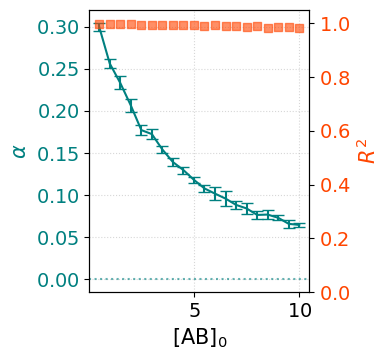

In [97]:
results = load_streamed_pickle("barrido_ab0_k1_0.0001_parallel.pkl")
plot_AB_barrido(results)

In [98]:
for el in [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]:
    results.pop(el)

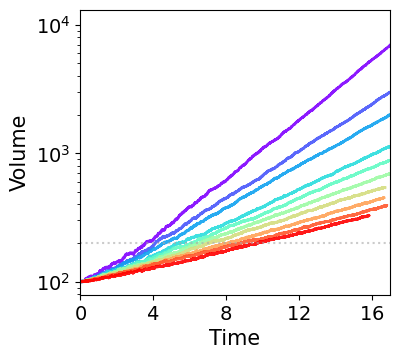

In [99]:
plot_all_volumes_AB(results,xlim= 17, fig_name= "ab0_lowk2_volumes")

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         5.0    0.119139   0.006427  0.990954
1        10.0    0.064735   0.004057  0.984562
2        15.0    0.041841   0.002034  0.975361
3        20.0    0.033402   0.003380  0.971825
4        25.0    0.026117   0.001567  0.969775
5        30.0    0.023492   0.002121  0.963984
6        35.0    0.019078   0.001599  0.961137
7        40.0    0.017345   0.001885  0.962904
8        45.0    0.015093   0.001424  0.957136
9        50.0    0.013800   0.001776  0.957441
10       55.0    0.012377   0.001444  0.966449
11       60.0    0.010600   0.000606  0.954323
12       65.0    0.010968   0.000870  0.969627
13       70.0    0.010520   0.000822  0.977337
14       75.0    0.009213   0.001287  0.970120
15       80.0    0.009253   0.000546  0.970284
16       85.0    0.008434   0.000601  0.965955
17       90.0    0.008264   0.000562  0.975315
18       95.0    0.007417   0.000620  0.966906
19      100.0    

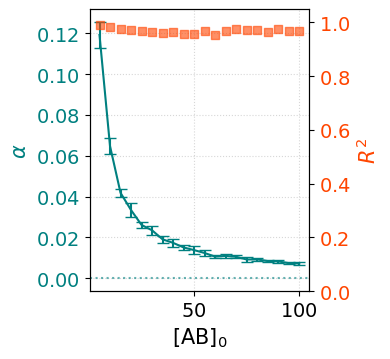

In [100]:
results = load_streamed_pickle("barrido_ab0_k1_0.0001_highiter.pkl")
plot_AB_barrido(results, fig_name= "ab0_lowk2")

In [101]:
fordeleting = 10 * np.array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5])
for el in fordeleting:
    results.pop(el)

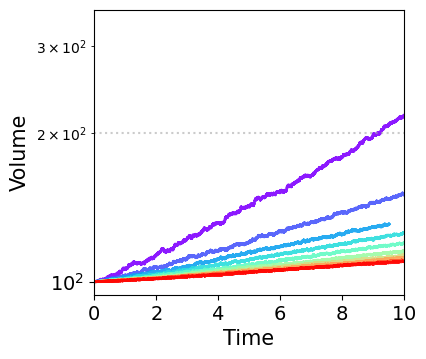

In [102]:

plot_all_volumes_AB(results, xlim=10)

#### k1 = 1

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    0.235082   0.003067  0.999814
1         1.0    0.179805   0.002246  0.999511
2         1.5    0.139770   0.002822  0.999556
3         2.0    0.101605   0.001668  0.998337
4         2.5    0.068495   0.002961  0.996236
5         3.0    0.042561   0.003889  0.991992
6         3.5    0.019368   0.005173  0.972926
7         4.0   -0.000323   0.002587  0.311151
8         4.5   -0.012162   0.006562  0.872155
9         5.0   -0.028290   0.005499  0.956616
10        5.5   -0.040721   0.004302  0.961251
11        6.0   -0.054175   0.009210  0.947396
12        6.5   -0.065092   0.004014  0.989337
13        7.0   -0.075407   0.008351  0.978358
14        7.5   -0.084606   0.006447  0.969608
15        8.0   -0.098894   0.003262  0.991445
16        8.5   -0.104834   0.004373  0.989172
17        9.0   -0.114171   0.010711  0.986709
18        9.5   -0.120338   0.010105  0.987470
19       10.0   -

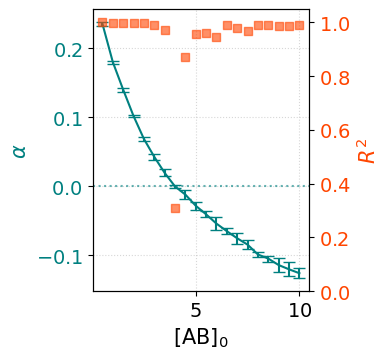

In [11]:
results = load_streamed_pickle("barrido_ab0_k1_1_parallel.pkl")
# 1. Processing the statistical data
# Assuming barrido_ab_k1_em4 is a dict: {concentration: [(ab, t, v), (ab, t, v), ...]}
for el in [0.0]:
    results.pop(el)
    


stats_results = []

for condition, replicates in results.items():
    alphas = []
    r2_values = []
    if not isinstance(replicates, tuple):
        for rep in replicates:
            # If rep is a dictionary {cond: (ab, t, v)}, get the tuple:
            if isinstance(rep, dict):
                # This gets the first value in the dict, which is your (ab, t, v) tuple
                data_tuple = list(rep.values())[0]
            else:
                data_tuple = rep
                
            res = get_alpha_single_run(condition, data_tuple) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
    else:
        res = get_alpha_single_run(condition, replicates) 
        alphas.append(res['Alpha'])
        r2_values.append(res['R^2'])
    
    stats_results.append({
        'Condition': condition,
        'Alpha_mean': np.mean(alphas),
        'Alpha_std': np.std(alphas),
        'R2_mean': np.mean(r2_values)
    })

# Convert to DataFrame or Sortable List for plotting
stats_results = pd.DataFrame(stats_results).sort_values('Condition')
print(stats_results)

# 2. Plotting with Error Bars
fig, ax1 = plt.subplots(figsize= (4,3.7)) 

# Primary Axis: Alpha with Error Bars
ax1.set_xlabel(r'$[\text{AB}]_0$', fontsize= label_fs) 
ax1.set_ylabel(r'$\alpha$', color="teal", fontsize= label_fs)

ax1.errorbar(stats_results['Condition'], stats_results['Alpha_mean'], 
             yerr=stats_results['Alpha_std'], color="teal", capsize=4, label=r'Mean $\alpha$')

ax1.tick_params(axis='y', labelcolor="teal", labelsize= tick_fs)
ax1.grid(True, linestyle=':', alpha=0.5, which='both')
ax1.axhline(y=0, color="teal", alpha=0.6, linestyle=":")
# ax1.set_xscale('log')
ax1.tick_params(axis='x', labelsize=tick_fs)  

# Secondary Axis: R^2
ax2 = ax1.twinx()  
ax2.set_ylabel(r'$R^2$', color="orangered", fontsize= label_fs)  
ax2.scatter(stats_results['Condition'], stats_results['R2_mean'], 
            color="orangered", marker='s', alpha=0.6)

ax2.tick_params(axis='y', labelcolor="orangered", labelsize= tick_fs)
ax2.set_ylim((0, 1.05))
# ax2.set_xscale('log')
ax2.tick_params(axis='x', labelsize=tick_fs)  
fig.tight_layout()
plt.savefig("../figures_TFM/ab0_mediumk2.png")
plt.show()


In [12]:
for el in [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]:
    results.pop(el)

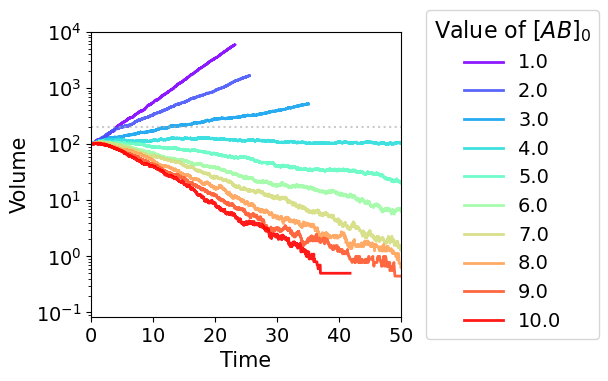

In [13]:
plot_all_volumes_AB(results, xlim = 50, fig_name="ab0_mediumk2_volumes")

#### k1 = 1e4

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    0.002083   0.003144  0.124845
1         1.0   -0.011704   0.001695  0.597405
2         1.5   -0.026596   0.003988  0.682696
3         2.0   -0.038766   0.002654  0.681069
4         2.5   -0.060916   0.004217  0.742274
5         3.0   -0.078469   0.004119  0.762911
6         3.5   -0.099929   0.001639  0.786634
7         4.0   -0.120623   0.004689  0.804394
8         4.5   -0.148354   0.018543  0.829783
9         5.0   -0.186882   0.015534  0.871091
10        5.5   -0.218747   0.016963  0.892151
11        6.0   -0.269396   0.008560  0.960612
12        6.5   -0.318253   0.006394  0.970826
13        7.0   -0.353777   0.016855  0.976534
14        7.5   -0.377352   0.018228  0.981334
15        8.0   -0.380154   0.015509  0.975079
16        8.5   -0.407163   0.015946  0.974366
17        9.0   -0.415850   0.018054  0.974202
18        9.5   -0.419834   0.026438  0.961845
19       10.0   -

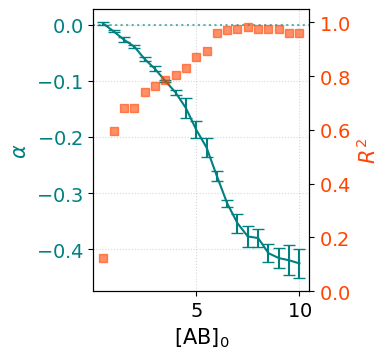

In [11]:
results = load_streamed_pickle("barrido_ab0_k1_10000.0_parallel.pkl")
plot_AB_barrido(results, fig_name= "ab0_highk2")

In [12]:
for el in [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]:
    results.pop(el)


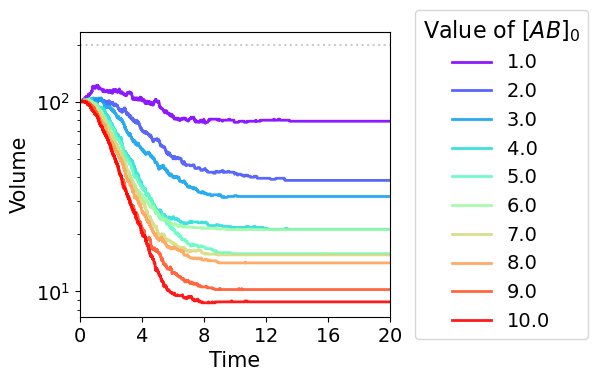

In [13]:
plot_all_volumes_AB(results, xlim= 20)

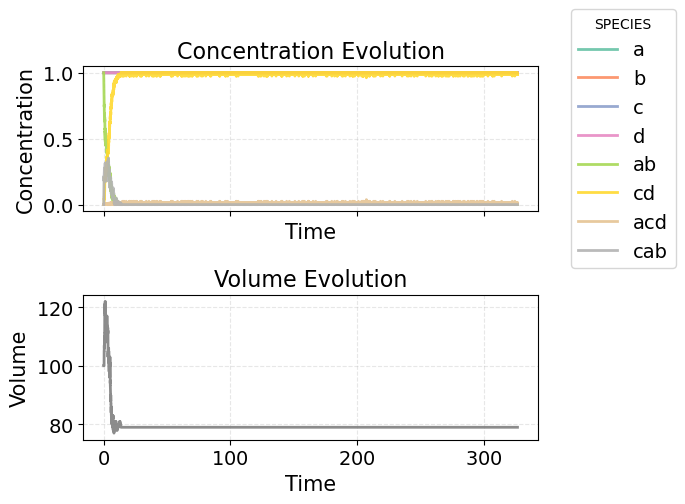

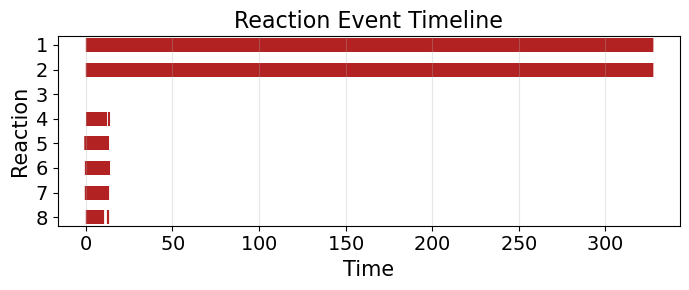

In [15]:
a,t,v = results[1.0][0]

plot(a, t, v, species)
plot_reaction_timeline(t, range(1,9), a)

## all k1

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_triple_volumes_AB(results_list, k_titles, xlim=None, ylim=None, lim=None, rep=0, fig_name=None):
    """
    results_list: List of 3 dictionaries [res1, res2, res3]
    k_titles: List of 3 strings for subplot titles [title1, title2, title3]
    """
    # Set up a wide figure for 3 side-by-side plots
    fig, axes = plt.subplots(3, 1, figsize=(4,8), sharey=True)
    
    for i, results in enumerate(results_list):
        ax = axes[i]
        
        # 1. Filtering Logic
        if lim is not None:
            filtered_conditions = [c for c in results.keys() if lim[0] < float(c) < lim[1]]
        else:
            filtered_conditions = list(results.keys())
            
        if not filtered_conditions:
            continue

        # 2. Color Gradient for this subplot
        color_gradient = plt.cm.rainbow(np.linspace(0, 1, len(filtered_conditions)))
        v_initial = None # For the horizontal line baseline

        # 3. Plotting individual lines
        for j, condition in enumerate(filtered_conditions):
            if j%2 != 0:  # Skip every other condition for clarity
                continue
            replicates = results[condition]
            
            # Extract data tuple
            if not isinstance(replicates, tuple):
                if isinstance(replicates[rep], dict):
                    data_tuple = list(replicates[rep].values())[0]
                else:
                    data_tuple = replicates[rep]
                a, t, v = data_tuple
            else:
                a, t, v = replicates
            
            if v_initial is None: v_initial = v[0]
                
            ax.plot(t, v, color=color_gradient[j], label=condition, alpha=0.9, linewidth=1.5)

        # 4. Subplot Formatting
        ax.set_title(k_titles[i], fontsize=title_fs)
        ax.set_yscale('log')
        ax.set_xlabel("Time", fontsize=label_fs)
        ax.set_ylabel("Volume", fontsize=label_fs)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax.tick_params(axis='both', labelsize=tick_fs)
        if i == 1:
            ax.legend(title=rf"$[AB]_0$", fontsize=legend_fs-2, title_fontsize=title_fs-2,
                      loc='center left', bbox_to_anchor=(1.05, 0.5), frameon=True, framealpha=0.7)
        if xlim: ax.set_xlim(0, xlim[i])
        if ylim: ax.set_ylim(ylim)
    
    plt.tight_layout()
    if fig_name:
        plt.savefig(f"../figures_TFM/{fig_name}.png", bbox_inches='tight')
    plt.show()

# --- Example Usage ---
# res_list = [results_k1_low, results_k1_med, results_k1_high]
# titles = [r'$k_1 = 10^{-2}$', r'$k_1 = 1

Successfully loaded 21 simulation results.
Successfully loaded 21 simulation results.
Successfully loaded 21 simulation results.


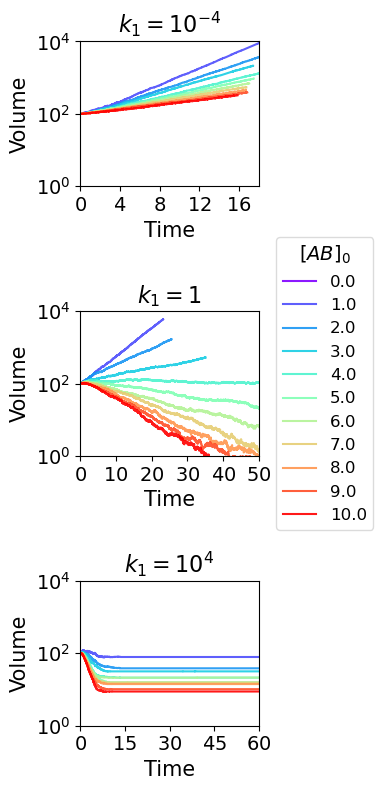

In [13]:
results_k1_low = load_streamed_pickle("barrido_ab0_k1_0.0001_parallel.pkl")
results_k1_med = load_streamed_pickle("barrido_ab0_k1_1_parallel.pkl")
results_k1_high = load_streamed_pickle("barrido_ab0_k1_10000.0_parallel.pkl")
plot_triple_volumes_AB([results_k1_low, results_k1_med, results_k1_high], 
                       [r'$k_1 = 10^{-4}$', r'$k_1 = 1$', r'$k_1 = 10^4$'], 
                       xlim=[18, 50, 60], fig_name="ab0_triple_volumes", ylim=(1, 1e4))

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_triple_AB_barrido(results_list, k_titles, fig_name=None):
    """
    results_list: List of 3 result dictionaries.
    k_titles: List of 3 strings for subplot titles.
    """
    fig, axes = plt.subplots(3, 1, figsize=(4,8))

    for i, results in enumerate(results_list):
        # Work on a copy so we don't modify your original data
        res_copy = results.copy()
        if 0.0 in res_copy: res_copy.pop(0.0)
        
        stats_results = []

        # 1. Stats Calculation
        for condition, replicates in res_copy.items():
            alphas = []
            r2_values = []
            
            # Standardize processing logic
            reps_list = replicates if isinstance(replicates, (list, tuple)) else [replicates]
            
            for rep in reps_list:
                data_tuple = list(rep.values())[0] if isinstance(rep, dict) else rep
                # Ensure we handle the data tuple format
                res = get_alpha_single_run(condition, data_tuple, values_used=1) 
                alphas.append(res['Alpha'])
                r2_values.append(res['R^2'])
            
            stats_results.append({
                'Condition': condition,
                'Alpha_mean': np.mean(alphas),
                'Alpha_std': np.std(alphas),
                'R2_mean': np.mean(r2_values)
            })

        df = pd.DataFrame(stats_results).sort_values('Condition')

        # 2. Plotting (Per subplot)
        ax1 = axes[i]
        
        # Primary Axis: Alpha
        ax1.set_xlabel(r'$[\text{AB}]_0$', fontsize=label_fs) 
        ax1.set_ylabel(r'$\alpha$', color="teal", fontsize=label_fs)
        
        ax1.errorbar(df['Condition'], df['Alpha_mean'], yerr=df['Alpha_std'], 
                     color="teal", capsize=3, label=r'Mean $\alpha$')
        ax1.tick_params(axis='y', labelcolor="teal", labelsize=tick_fs-2)
        ax1.set_title(k_titles[i], fontsize=title_fs)
        ax1.axhline(y=0, color="teal", alpha=0.5, linestyle=":")
        ax1.tick_params(axis='x', labelsize=tick_fs-2)
        ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

        # Secondary Axis: R^2
        ax2 = ax1.twinx() 
        ax2.set_ylabel(r'$R^2$', color="orangered", fontsize=label_fs)
        
        ax2.scatter(df['Condition'], df['R2_mean'], color="orangered", marker='s', alpha=0.6)
        ax2.tick_params(axis='y', labelcolor="orangered", labelsize=tick_fs-2)
        ax2.set_ylim((0, 1.05))
        ax2.tick_params(axis='x', labelsize=tick_fs-2)
        ax2.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))


    plt.tight_layout()
    if fig_name:
        plt.savefig(f"../figures_TFM/{fig_name}.png", bbox_inches='tight')
    plt.show()

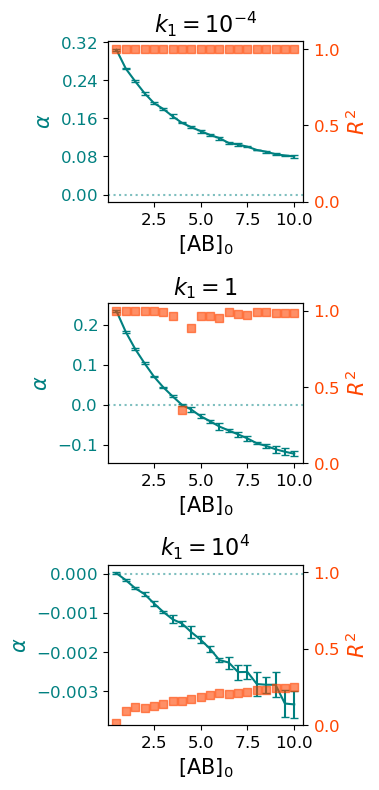

In [15]:
plot_triple_AB_barrido([results_k1_low, results_k1_med, results_k1_high], 
                       [r'$k_1 = 10^{-4}$', r'$k_1 = 1$', r'$k_1 = 10^4$'], 
                       fig_name="ab0_triple_barrido")

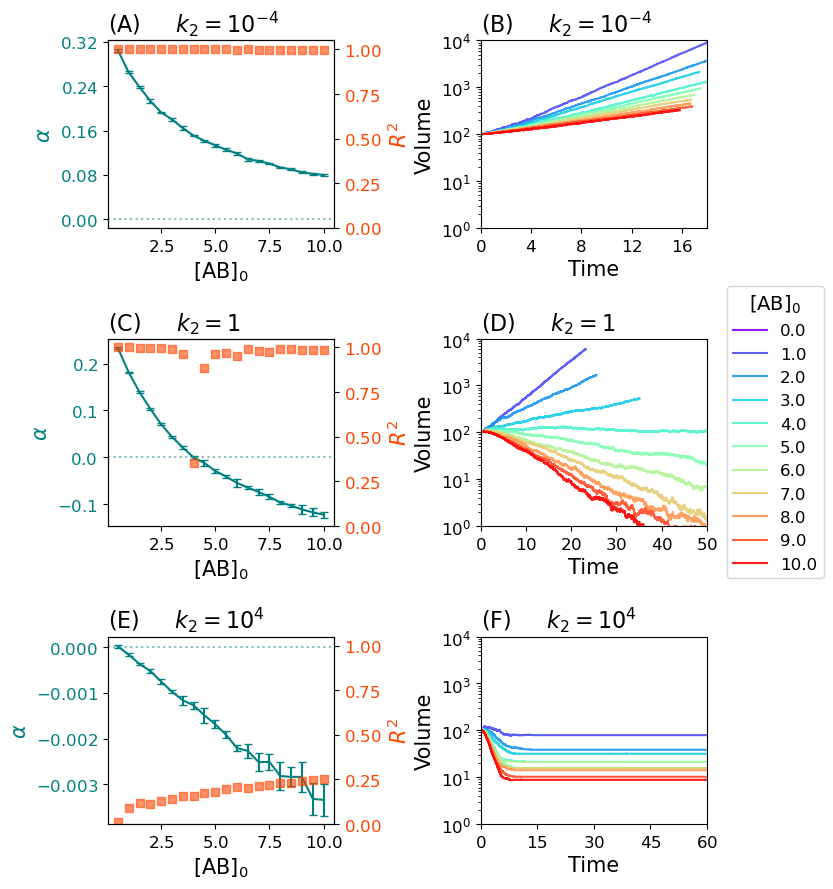

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

def plot_combined_AB(results_list, xlim=None, ylim=None, lim=None, rep=0, fig_name=None):
    """
    results_list: List of 3 result dictionaries.
    k_titles: List of 3 strings for subplot titles.
    Plots a 3x2 grid: Left column is Alpha/R^2 Sweep, Right column is Volume Evolution.
    """
    # Set up a 3x2 figure
    fig, axes = plt.subplots(3, 2, figsize=(10,9))
    titles = [r"(A)" +"\t"+r"$k_2 = 10^{-4}$", r"(B)"+"\t"+r"$k_2 = 10^{-4}$", r"(C)"+"\t"+r"$k_2 = 1$",
                r"(D)"+"\t"+r"$k_2 = 1$", r"(E)"+"\t"+r"$k_2 = 10^4$", r"(F)"+"\t"+r"$k_2 = 10^4$"]
    for i, results in enumerate(results_list):
        ax_sweep = axes[i, 0]
        ax_vol = axes[i, 1]

        # ==========================================
        # LEFT COLUMN: BARRIDO / SWEEP (Alpha & R^2)
        # ==========================================
        res_copy = results.copy()
        if 0.0 in res_copy: res_copy.pop(0.0)
        
        stats_results = []
        for condition, replicates in res_copy.items():
            alphas = []
            r2_values = []
            
            reps_list = replicates if isinstance(replicates, (list, tuple)) else [replicates]
            
            for r in reps_list:
                data_tuple = list(r.values())[0] if isinstance(r, dict) else r
                res = get_alpha_single_run(condition, data_tuple, values_used=1) 
                alphas.append(res['Alpha'])
                r2_values.append(res['R^2'])
            
            stats_results.append({
                'Condition': condition,
                'Alpha_mean': np.mean(alphas),
                'Alpha_std': np.std(alphas),
                'R2_mean': np.mean(r2_values)
            })

        df = pd.DataFrame(stats_results).sort_values('Condition')

        # Primary Axis: Alpha
        ax_sweep.set_xlabel(r'$[\text{AB}]_0$', fontsize=label_fs) 
        ax_sweep.set_ylabel(r'$\alpha$', color="teal", fontsize=label_fs)
        ax_sweep.errorbar(df['Condition'], df['Alpha_mean'], yerr=df['Alpha_std'], 
                          color="teal", capsize=3, label=r'Mean $\alpha$')
        ax_sweep.tick_params(axis='y', labelcolor="teal", labelsize=tick_fs-2)
        ax_sweep.set_title(titles.pop(0), fontsize=title_fs, loc='left')
        ax_sweep.axhline(y=0, color="teal", alpha=0.5, linestyle=":")
        ax_sweep.tick_params(axis='x', labelsize=tick_fs-2)
        ax_sweep.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax_sweep.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

        # Secondary Axis: R^2
        ax2_sweep = ax_sweep.twinx() 
        ax2_sweep.set_ylabel(r'$R^2$', color="orangered", fontsize=label_fs)
        ax2_sweep.scatter(df['Condition'], df['R2_mean'], color="orangered", marker='s', alpha=0.6)
        ax2_sweep.tick_params(axis='y', labelcolor="orangered", labelsize=tick_fs-2)
        ax2_sweep.set_ylim((0, 1.05))
        ax2_sweep.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))


        # ==========================================
        # RIGHT COLUMN: VOLUMES EVOLUTION
        # ==========================================
        if lim is not None:
            filtered_conditions = [c for c in results.keys() if lim[0] < float(c) < lim[1]]
        else:
            filtered_conditions = list(results.keys())
            
        if filtered_conditions:
            color_gradient = plt.cm.rainbow(np.linspace(0, 1, len(filtered_conditions)))

            for j, condition in enumerate(filtered_conditions):
                if j % 2 != 0:  # Skip every other condition for clarity
                    continue
                replicates = results[condition]
                
                # Extract data tuple
                if not isinstance(replicates, tuple):
                    if isinstance(replicates[rep], dict):
                        data_tuple = list(replicates[rep].values())[0]
                    else:
                        data_tuple = replicates[rep]
                    a, t, v = data_tuple
                else:
                    a, t, v = replicates
                    
                ax_vol.plot(t, v, color=color_gradient[j], label=condition, alpha=0.9, linewidth=1.5)

        ax_vol.set_title(titles.pop(0), fontsize=title_fs, loc= 'left')
        ax_vol.set_yscale('log')
        ax_vol.set_xlabel("Time", fontsize=label_fs)
        ax_vol.set_ylabel("Volume", fontsize=label_fs)
        ax_vol.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax_vol.tick_params(axis='both', labelsize=tick_fs-2)
        
   
        if i == 1:
            leg = ax_vol.legend(title=rf"$[\text{{AB}}]_0$", fontsize=legend_fs-2, title_fontsize=title_fs-2,
                                loc='center left', bbox_to_anchor=(1.05, 0.5))
            
   
        
        if xlim: ax_vol.set_xlim(0, xlim[i])
        if ylim: ax_vol.set_ylim(ylim)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    
    if fig_name:
        plt.savefig(f"../figures_TFM/{fig_name}.png", bbox_inches='tight', dpi=300)
    plt.show()
   

# --- Example Usage ---
plot_combined_AB([results_k1_low, results_k1_med, results_k1_high], 
                 xlim=[18, 50, 60], fig_name="ab0_combined", ylim=(1, 1e4))

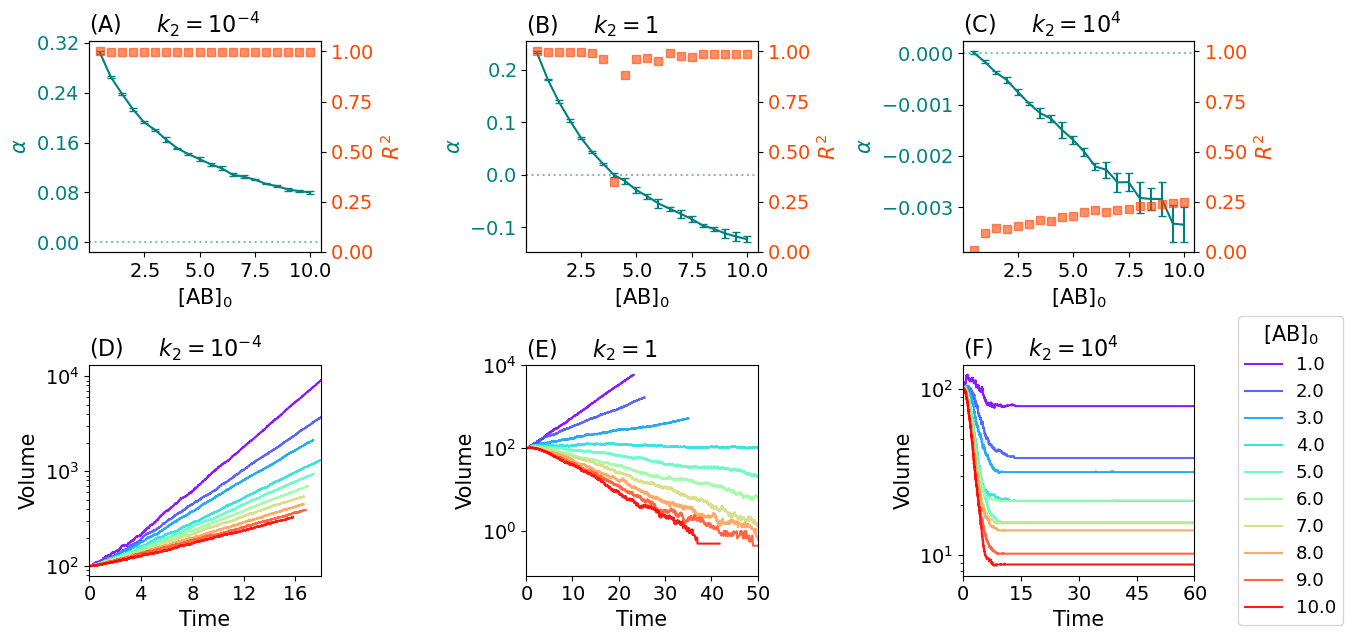

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

def plot_combined_AB(results_list, xlim=None, ylim=None, lim=None, rep=0, fig_name=None):
    """
    results_list: List of 3 result dictionaries.
    Plots a 2x3 grid: Top row is Alpha/R^2 Sweep, Bottom row is Volume Evolution.
    """
    # Set up a 2x3 figure, making it wider than it is tall (e.g., 15x6)
    fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
    
    # Split titles so (A,B,C) go on top, and (D,E,F) go on bottom
    titles_sweep = [r"(A)" +"\t"+r"$k_2 = 10^{-4}$", r"(B)"+"\t"+r"$k_2 = 1$", r"(C)"+"\t"+r"$k_2 = 10^4$"]
    titles_vol = [r"(D)"+"\t"+r"$k_2 = 10^{-4}$", r"(E)"+"\t"+r"$k_2 = 1$", r"(F)"+"\t"+r"$k_2 = 10^4$"]
    
    for i, results in enumerate(results_list):
        # Top row for sweeps, Bottom row for volumes
        ax_sweep = axes[0, i]
        ax_vol = axes[1, i]

        # ==========================================
        # TOP ROW: BARRIDO / SWEEP (Alpha & R^2)
        # ==========================================
        res_copy = results.copy()
        if 0.0 in res_copy: res_copy.pop(0.0)
        
        stats_results = []
        for condition, replicates in res_copy.items():
            alphas = []
            r2_values = []
            
            reps_list = replicates if isinstance(replicates, (list, tuple)) else [replicates]
            
            for r in reps_list:
                data_tuple = list(r.values())[0] if isinstance(r, dict) else r
                res = get_alpha_single_run(condition, data_tuple, values_used=1) 
                alphas.append(res['Alpha'])
                r2_values.append(res['R^2'])
            
            stats_results.append({
                'Condition': condition,
                'Alpha_mean': np.mean(alphas),
                'Alpha_std': np.std(alphas),
                'R2_mean': np.mean(r2_values)
            })

        df = pd.DataFrame(stats_results).sort_values('Condition')

        # Primary Axis: Alpha
        ax_sweep.set_xlabel(r'$[\text{AB}]_0$', fontsize=label_fs) 
        ax_sweep.set_ylabel(r'$\alpha$', color="teal", fontsize=label_fs)
        ax_sweep.errorbar(df['Condition'], df['Alpha_mean'], yerr=df['Alpha_std'], 
                          color="teal", capsize=3, label=r'Mean $\alpha$')
        ax_sweep.tick_params(axis='y', labelcolor="teal", labelsize=tick_fs)
        ax_sweep.set_title(titles_sweep[i], fontsize=title_fs, loc='left')
        ax_sweep.axhline(y=0, color="teal", alpha=0.5, linestyle=":")
        ax_sweep.tick_params(axis='x', labelsize=tick_fs)
        ax_sweep.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax_sweep.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

        # Secondary Axis: R^2
        ax2_sweep = ax_sweep.twinx() 
        ax2_sweep.set_ylabel(r'$R^2$', color="orangered", fontsize=label_fs)
        ax2_sweep.scatter(df['Condition'], df['R2_mean'], color="orangered", marker='s', alpha=0.6)
        ax2_sweep.tick_params(axis='y', labelcolor="orangered", labelsize=tick_fs)
        ax2_sweep.set_ylim((0, 1.05))
        ax2_sweep.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))


        # ==========================================
        # BOTTOM ROW: VOLUMES EVOLUTION
        # ==========================================
        if lim is not None:
            filtered_conditions = [c for c in results.keys() if lim[0] < float(c) < lim[1]]
        else:
            filtered_conditions = list(results.keys())
            
        # 1. Sort the conditions numerically from lowest to highest
        filtered_conditions = sorted(filtered_conditions, key=float)
        
        # 2. REMOVE THE LOWEST CONDITION (Index 0)
        if len(filtered_conditions) > 0:
            filtered_conditions.pop(0)
            filtered_conditions.pop(0)

            
        # 3. Proceed with the color gradient and plotting as normal
        if filtered_conditions:
            color_gradient = plt.cm.rainbow(np.linspace(0, 1, len(filtered_conditions)))

            for j, condition in enumerate(filtered_conditions):
                if j % 2 != 0:  # Skip every other condition for clarity
                    continue
                replicates = results[condition]
                
                # Extract data tuple
                if not isinstance(replicates, tuple):
                    if isinstance(replicates[rep], dict):
                        data_tuple = list(replicates[rep].values())[0]
                    else:
                        data_tuple = replicates[rep]
                    a, t, v = data_tuple
                else:
                    a, t, v = replicates
                    
                ax_vol.plot(t, v, color=color_gradient[j], label=condition, alpha=0.9, linewidth=1.5)

        ax_vol.set_title(titles_vol[i], fontsize=title_fs, loc='left')
        ax_vol.set_yscale('log')
        ax_vol.set_xlabel("Time", fontsize=label_fs)
        ax_vol.set_ylabel("Volume", fontsize=label_fs)
        ax_vol.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax_vol.tick_params(axis='both', labelsize=tick_fs)
        
        # Move legend to the far right plot (i == 2)
        if i == 2:
            leg = ax_vol.legend(title=rf"$[\text{{AB}}]_0$", fontsize=legend_fs-1, title_fontsize=title_fs-1,
                                loc='center left', bbox_to_anchor=(1.15, 0.5))
            
        if xlim: ax_vol.set_xlim(0, xlim[i])
        if ylim: ax_vol.set_ylim(ylim)
        
    # Adjusted rect right-margin to 0.92 since the figure is much wider now (15 inches)
    # This leaves just enough room for the legend on the far right.
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    
    if fig_name:
        plt.savefig(f"../figures_TFM/{fig_name}.png", bbox_inches='tight', dpi=300)
    plt.show()


# --- Example Usage ---
plot_combined_AB([results_k1_low, results_k1_med, results_k1_high], 
                 xlim=[18, 50, 60], fig_name="ab0_combined")

## k2 = 1e-4

Successfully loaded 19 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    0.000092   0.000087  0.369160
1         1.0    0.000046   0.000061  0.080716
2         1.5    0.000029   0.000037  0.269206
3         2.0   -0.000007   0.000012 -2.156712
4         2.5   -0.000005   0.000007  0.059916
5         3.0    0.000004   0.000019  0.520043
6         3.5   -0.000010   0.000006  0.628639
7         4.0   -0.000009   0.000004  0.601317
8         4.5   -0.000012   0.000009  0.626451
9         5.0   -0.000017   0.000005  0.838342
10        5.5   -0.000020   0.000005  0.906618
11        6.0   -0.000009   0.000005  0.630597
12        6.5   -0.000024   0.000010  0.928426
13        7.0   -0.000010   0.000007  0.659882
14        7.5   -0.000013   0.000004  0.856136
15        8.0   -0.000020   0.000008  0.867596
16        8.5   -0.000024   0.000008  0.914490
17        9.0   -0.000017   0.000011  0.745217


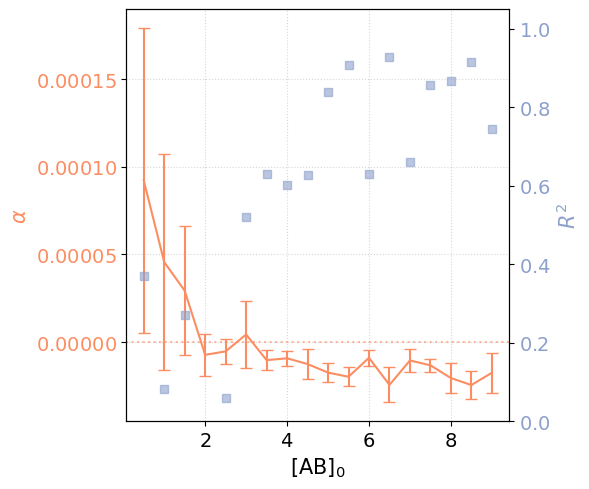

In [ ]:
results = load_streamed_pickle("barrido_ab0_k2_0.0001_parallel.pkl")
results.pop(0.0)
stats_results = []

for condition, replicates in results.items():
    alphas = []
    r2_values = []
    if not isinstance(replicates, tuple):
        for rep in replicates:
            # If rep is a dictionary {cond: (ab, t, v)}, get the tuple:
            if isinstance(rep, dict):
                # This gets the first value in the dict, which is your (ab, t, v) tuple
                data_tuple = list(rep.values())[0]
            else:
                data_tuple = rep
                
            res = get_alpha_single_run(condition, data_tuple) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
    else:
        res = get_alpha_single_run(condition, replicates) 
        alphas.append(res['Alpha'])
        r2_values.append(res['R^2'])
    
    stats_results.append({
        'Condition': condition,
        'Alpha_mean': np.mean(alphas),
        'Alpha_std': np.std(alphas),
        'R2_mean': np.mean(r2_values)
    })

# Convert to DataFrame or Sortable List for plotting
stats_results = pd.DataFrame(stats_results).sort_values('Condition')
print(stats_results)

# Plotting with Error Bars
fig, ax1 = plt.subplots(figsize= (6,5))
# Primary Axis: Alpha with Error Bars
ax1.set_xlabel(r'$[\text{AB}]_0$', fontsize= label_fs) 
ax1.set_ylabel(r'$\alpha$', color=colors[1], fontsize= label_fs)

ax1.errorbar(stats_results['Condition'], stats_results['Alpha_mean'], 
             yerr=stats_results['Alpha_std'], color=colors[1], capsize=4, label=r'Mean $\alpha$')

ax1.tick_params(axis='y', labelcolor=colors[1], labelsize= tick_fs)
ax1.grid(True, linestyle=':', alpha=0.5, which='both')
ax1.axhline(y=0, color=colors[1], alpha=0.6, linestyle=":")
# ax1.set_xscale('log')
ax1.tick_params(axis='x', labelsize=tick_fs)  

# Secondary Axis: R^2
ax2 = ax1.twinx()  
ax2.set_ylabel(r'$R^2$', color=colors[2], fontsize= label_fs)  
ax2.scatter(stats_results['Condition'], stats_results['R2_mean'], 
            color=colors[2], marker='s', alpha=0.6)

ax2.tick_params(axis='y', labelcolor=colors[2], labelsize= tick_fs)
ax2.set_ylim((0, 1.05))
# ax2.set_xscale('log')
ax2.tick_params(axis='x', labelsize=tick_fs)  
fig.tight_layout()
plt.show()

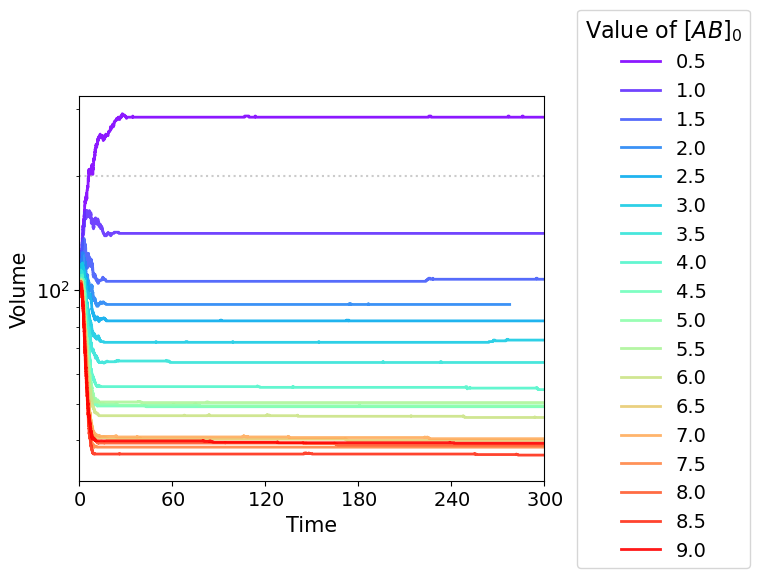

In [133]:
plot_all_volumes_AB(results, xlim = 300)

## k2 = 1

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    0.235475   0.002461  0.999822
1         1.0    0.180273   0.003522  0.999631
2         1.5    0.133738   0.002121  0.999103
3         2.0    0.100891   0.002716  0.998841
4         2.5    0.067380   0.002558  0.997525
5         3.0    0.045587   0.001260  0.994061
6         3.5    0.021020   0.005372  0.958692
7         4.0   -0.000414   0.001690  0.183900
8         4.5   -0.015549   0.004624  0.925267
9         5.0   -0.028867   0.005601  0.941511
10        5.5   -0.037182   0.005402  0.949214
11        6.0   -0.060050   0.008122  0.976792
12        6.5   -0.059633   0.005999  0.957218
13        7.0   -0.065344   0.007782  0.943877
14        7.5   -0.068408   0.011595  0.920571
15        8.0   -0.106064   0.008032  0.988940
16        8.5   -0.103624   0.017056  0.964258
17        9.0   -0.119223   0.011312  0.985199
18        9.5   -0.115062   0.003890  0.986797
19       10.0   -

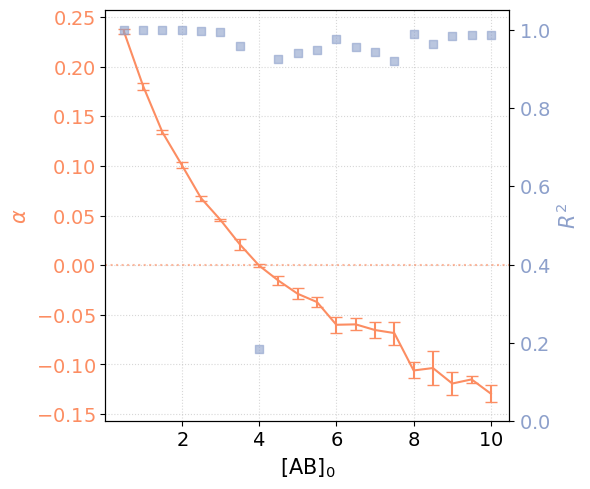

In [ ]:
results = load_streamed_pickle("barrido_ab0_k2_1_parallel.pkl")
results.pop(0.0)
stats_results = []

for condition, replicates in results.items():
    alphas = []
    r2_values = []
    if not isinstance(replicates, tuple):
        for rep in replicates:
            # If rep is a dictionary {cond: (ab, t, v)}, get the tuple:
            if isinstance(rep, dict):
                # This gets the first value in the dict, which is your (ab, t, v) tuple
                data_tuple = list(rep.values())[0]
            else:
                data_tuple = rep
                
            res = get_alpha_single_run(condition, data_tuple) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
    else:
        res = get_alpha_single_run(condition, replicates) 
        alphas.append(res['Alpha'])
        r2_values.append(res['R^2'])
    
    stats_results.append({
        'Condition': condition,
        'Alpha_mean': np.mean(alphas),
        'Alpha_std': np.std(alphas),
        'R2_mean': np.mean(r2_values)
    })

# Convert to DataFrame or Sortable List for plotting
stats_results = pd.DataFrame(stats_results).sort_values('Condition')
print(stats_results)

fig, ax1 = plt.subplots(figsize= (6,5)) 

# Primary Axis: Alpha with Error Bars
ax1.set_xlabel(r'$[\text{AB}]_0$', fontsize= label_fs) 
ax1.set_ylabel(r'$\alpha$', color=colors[1], fontsize= label_fs)

ax1.errorbar(stats_results['Condition'], stats_results['Alpha_mean'], 
             yerr=stats_results['Alpha_std'], color=colors[1], capsize=4, label=r'Mean $\alpha$')

ax1.tick_params(axis='y', labelcolor=colors[1], labelsize= tick_fs)
ax1.grid(True, linestyle=':', alpha=0.5, which='both')
ax1.axhline(y=0, color=colors[1], alpha=0.6, linestyle=":")
# ax1.set_xscale('log')
ax1.tick_params(axis='x', labelsize=tick_fs)  

# Secondary Axis: R^2
ax2 = ax1.twinx()  
ax2.set_ylabel(r'$R^2$', color=colors[2], fontsize= label_fs)  
ax2.scatter(stats_results['Condition'], stats_results['R2_mean'], 
            color=colors[2], marker='s', alpha=0.6)

ax2.tick_params(axis='y', labelcolor=colors[2], labelsize= tick_fs)
ax2.set_ylim((0, 1.05))
# ax2.set_xscale('log')
ax2.tick_params(axis='x', labelsize=tick_fs)  
fig.tight_layout()
plt.show()

## k2 = 1e4

Successfully loaded 21 simulation results.
    Condition  Alpha_mean  Alpha_std   R2_mean
0         0.5    0.458941   0.006209  0.999874
1         1.0    0.401254   0.007193  0.999846
2         1.5    0.352531   0.003810  0.999819
3         2.0    0.312015   0.003069  0.999713
4         2.5    0.281685   0.004785  0.999636
5         3.0    0.251155   0.007553  0.999749
6         3.5    0.230004   0.006612  0.999545
7         4.0    0.207743   0.004006  0.999402
8         4.5    0.192616   0.009932  0.999238
9         5.0    0.174288   0.004680  0.999250
10        5.5    0.164371   0.003667  0.998788
11        6.0    0.154233   0.005093  0.999482
12        6.5    0.140938   0.002738  0.998785
13        7.0    0.133619   0.003122  0.998815
14        7.5    0.124082   0.002852  0.999048
15        8.0    0.120009   0.002523  0.999000
16        8.5    0.114567   0.003415  0.998352
17        9.0    0.107525   0.004653  0.999009
18        9.5    0.099182   0.002493  0.998539
19       10.0    

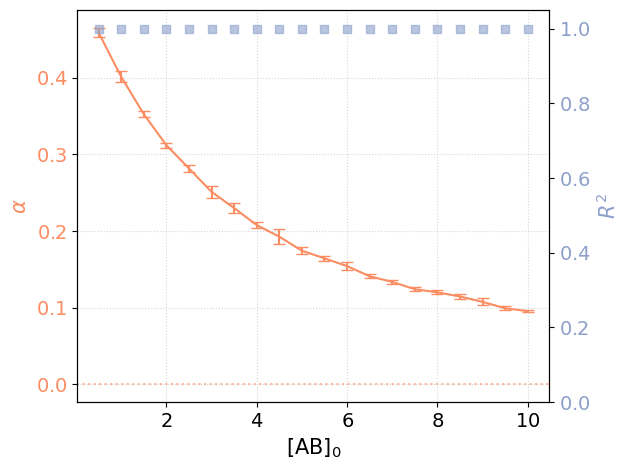

In [ ]:
results = load_streamed_pickle("barrido_ab0_k2_10000.0_parallel.pkl")
results.pop(0.0)

stats_results = []

for condition, replicates in results.items():
    alphas = []
    r2_values = []
    if not isinstance(replicates, tuple):
        for rep in replicates:
            # If rep is a dictionary {cond: (ab, t, v)}, get the tuple:
            if isinstance(rep, dict):
                # This gets the first value in the dict, which is your (ab, t, v) tuple
                data_tuple = list(rep.values())[0]
            else:
                data_tuple = rep
                
            res = get_alpha_single_run(condition, data_tuple) 
            alphas.append(res['Alpha'])
            r2_values.append(res['R^2'])
    else:
        res = get_alpha_single_run(condition, replicates) 
        alphas.append(res['Alpha'])
        r2_values.append(res['R^2'])
    
    stats_results.append({
        'Condition': condition,
        'Alpha_mean': np.mean(alphas),
        'Alpha_std': np.std(alphas),
        'R2_mean': np.mean(r2_values)
    })

# Convert to DataFrame or Sortable List for plotting
stats_results = pd.DataFrame(stats_results).sort_values('Condition')
print(stats_results)

# Plotting with Error Bars
fig, ax1 = plt.subplots()

# Primary Axis: Alpha with Error Bars
ax1.set_xlabel(r'$[\text{AB}]_0$', fontsize= label_fs) 
ax1.set_ylabel(r'$\alpha$', color=colors[1], fontsize= label_fs)

ax1.errorbar(stats_results['Condition'], stats_results['Alpha_mean'], 
             yerr=stats_results['Alpha_std'], color=colors[1], capsize=4, label=r'Mean $\alpha$')

ax1.tick_params(axis='y', labelcolor=colors[1], labelsize= tick_fs)
ax1.grid(True, linestyle=':', alpha=0.5, which='both')
ax1.axhline(y=0, color=colors[1], alpha=0.6, linestyle=":")
# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.tick_params(axis='x', labelsize=tick_fs)  

# Secondary Axis: R^2
ax2 = ax1.twinx()  
ax2.set_ylabel(r'$R^2$', color=colors[2], fontsize= label_fs)  
ax2.scatter(stats_results['Condition'], stats_results['R2_mean'], 
            color=colors[2], marker='s', alpha=0.6)

ax2.tick_params(axis='y', labelcolor=colors[2], labelsize= tick_fs)
ax2.set_ylim((0, 1.05))
# ax2.set_xscale('log')
ax2.tick_params(axis='x', labelsize=tick_fs)  
fig.tight_layout()
plt.show()